# D1 自测结果表
|项目|自评(会/半会/不会)|优先级(高/中/低)|补法|
|----|----|----|----|
|pandas merge|会 |低 | |
|pandas crosstab/pivot|会 |低 | |
|pandas 缺失值+describe统计|会 |低 | |
|SQL JOIN| 会| | |
|SQL窗口函数| 会| | |
|sklearn train_test_split| 会| | |
|sklearn confusion_matrix| 不会| | |
|sklearn cross_val_score| 会| | |
|sklearn roc_auc_score| 不会| | |
|LightGBM调包| 会| | |
|Git/GitHub|不会|高|D1全天实操练习|


## 题目 1：读取 csv 基础统计

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========直接生成测试数据（不需要外部文件）==========
np.random.seed(42)
n_rows = 300
df = pd.DataFrame({
    "user_id": list(range(n_rows)),
    "age": np.random.randint(18, 60, size=n_rows),
    "monthly_fee": np.round(np.random.uniform(20,120,size=n_rows),2),
    "is_vip": np.random.choice([0,1], size=n_rows, p=[0.7,0.3]),
})
# 人为制造部分缺失值
df.loc[np.random.choice(df.index, 15), "age"] = np.nan

# 可选：如果你想模拟读csv，把内存df保存成本地文件再读取
df.to_csv("./test_d1.csv", index=False)
df = pd.read_csv("./test_d1.csv")


In [2]:
# ----------------任务开始，请补全代码----------------
# 任务1：统计每列缺失数量
df.isnull().sum()
# missing = ____________
# print("每列缺失值:\n", missing)


user_id         0
age            14
monthly_fee     0
is_vip          0
dtype: int64

          user_id         age  monthly_fee      is_vip
count  300.000000  286.000000   300.000000  300.000000
mean   149.500000   39.108392    68.931033    0.313333
std     86.746758   12.420080    29.075307    0.464624
min      0.000000   18.000000    20.520000    0.000000
25%     74.750000   28.000000    45.022500    0.000000
50%    149.500000   41.000000    67.380000    0.000000
75%    224.250000   50.000000    93.295000    1.000000
max    299.000000   59.000000   119.590000    1.000000


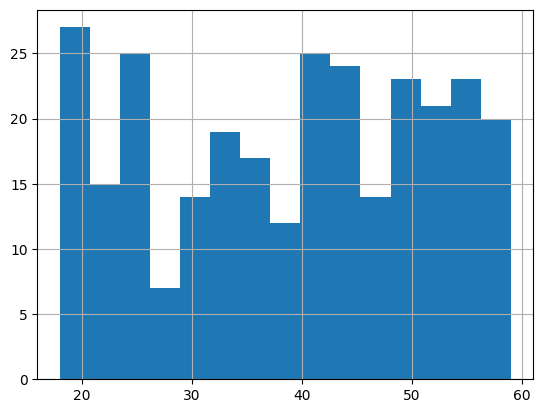

In [3]:
# 任务2：数值列describe描述统计
print(df.describe())

# 任务3：对 age 列绘制hist直方图
df['age'].hist(bins=15)
plt.show()


## 题目 2：字典频次统计，输出频次 Top5

In [6]:
data_list = ["apple","banana","apple","orange","banana","apple","pear",
             "banana","grape","apple","pear","banana","orange","apple","grape"]

freq_dict = {}
# --------你的代码写这里：用dict完成计数--------
for i in data_list:
    if i not in freq_dict.keys():
        freq_dict[i] = 1
    else:
        freq_dict[i] += 1

freq_dict

# 字典频次统计，输出频次 Top5
freq_dict_sorted = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)
print(freq_dict_sorted[:5])

[('apple', 5), ('banana', 4), ('orange', 2), ('pear', 2), ('grape', 2)]


## 题目 3：封装函数 summarize_csv，增加异常捕获 try‑except

In [10]:
def summarize_csv(path, col, top_n=5):
    try:
        df = pd.read_csv(path)[col]

    except FileNotFoundError:
        print(f"File not found: {path}")
        return None
    except KeyError:
        print(f"Column not found: {col}")
        return None
    except pd.errors.ParserError:
        print(f"Error parsing file: {path}")

    df = df.value_counts().nlargest(top_n)
    return df

# =========测试调用，使用上面生成的test_d1.csv=========
print(summarize_csv("./test_d1.csv", "is_vip", top_n=3))
# 故意传入错误路径测试异常逻辑
print(summarize_csv("./not_exist_file.csv", "is_vip"))
# 故意传入不存在列名测试异常逻辑
print(summarize_csv("./test_d1.csv", "not_exist_col"))

is_vip
0    206
1     94
Name: count, dtype: int64
File not found: ./not_exist_file.csv
None
Column not found: not_exist_col
None
